# Analyzing data

[Download notebook](notebooks/09_analyzing_data.ipynb).

In this chapter, we learn about statistical analysis with `scipy.stats`,
including descriptive statistics, probability distributions, statistical
tests, and maximum likelihood estimation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Descriptive statistics (`scipy.stats`)

The `scipy.stats` module provides functions for descriptive statistics
and statistical tests. Here, `data` is a 1d array or list.

- `stats.describe(data)`: returns count, min, max, mean, variance,
  skewness, kurtosis.
- `stats.tmean(data)`: trimmed mean.
- `stats.tstd(data)`: trimmed standard deviation.
- `stats.tvar(data)`: trimmed variance.
- `stats.pearsonr(x, y)`: Pearson correlation coefficient and p-value.
- `stats.spearmanr(x, y)`: Spearman rank correlation and p-value.

In [2]:
data = [1, 2, 3, 4, 5, 6, 7, 8]
result = stats.describe(data)
print(result)

DescribeResult(nobs=np.int64(8), minmax=(np.int64(1), np.int64(8)), mean=np.float64(4.5), variance=np.float64(6.0), skewness=np.float64(0.0), kurtosis=np.float64(-1.2380952380952381))

In [3]:
data = np.array([2.3, 4.1, 3.7, 5.2, 4.8, 3.3])
print("trimmed mean =", stats.tmean(data))
print("std =", stats.tstd(data))
print("median =", np.median(data))

trimmed mean = 3.9000000000000004
std = 1.0488088481701514
median = 3.9

In [4]:
# correlation
rng = np.random.default_rng(0)
x = rng.normal(size=50)
y = 2 * x + 0.5 * rng.normal(size=50)

r, p_value = stats.pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {p_value:.6f}")

Pearson r = 0.9621, p-value = 0.000000

## Probability distributions (`scipy.stats`)

`scipy.stats` provides a large number of probability distributions. Each
distribution object has a common interface. Here, `dist` is a
distribution object (e.g. `stats.norm`, `stats.expon`, `stats.poisson`).

- `dist.rvs(size=n)`: draw `n` random samples.
- `dist.pdf(x)` / `dist.pmf(x)`: density / probability mass function.
- `dist.cdf(x)`: cumulative distribution function.
- `dist.ppf(q)`: quantile function (inverse of `cdf`).
- `dist.mean()`, `dist.var()`, `dist.std()`: theoretical moments.
- `dist.fit(data)`: estimate parameters from data (maximum likelihood).

Each distribution takes its own parameters,
e.g. `stats.norm(loc=mu, scale=sigma)`, `stats.poisson(mu=lam)`,
`stats.binom(n=n, p=p)`. See the `scipy.stats` documentation for the
full list.

For continuous distributions, the location-scale convention is used:
`stats.norm(loc=mu, scale=sigma)` gives $\mathcal{N}(\mu, \sigma^2)$.

In [5]:
# standard normal
print("mean =", stats.norm.mean())
print("pdf(0) =", stats.norm.pdf(0))
print("cdf(1.96) =", stats.norm.cdf(1.96))
print("ppf(0.975) =", stats.norm.ppf(0.975))

mean = 0.0
pdf(0) = 0.3989422804014327
cdf(1.96) = 0.9750021048517795
ppf(0.975) = 1.959963984540054

In [6]:
# normal with given parameters
dist = stats.norm(loc=3, scale=2)
samples = dist.rvs(size=5, random_state=42)
print("samples:", samples)
print("mean =", dist.mean())
print("variance =", dist.var())

samples: [3.99342831 2.7234714  4.29537708 6.04605971 2.53169325]
mean = 3.0
variance = 4.0

In [7]:
# exponential
print("Exp(1) mean =", stats.expon.mean())
print("Exp(1) samples:", stats.expon.rvs(size=5, random_state=0))

Exp(1) mean = 1.0
Exp(1) samples: [0.79587451 1.25593076 0.92322315 0.78720115 0.55104849]

In [8]:
# Poisson
print("Poisson(3) pmf(2) =", stats.poisson.pmf(2, mu=3))

Poisson(3) pmf(2) = 0.22404180765538775

In [9]:
# binomial
print("Binom(10, 0.3) pmf(3) =", stats.binom.pmf(3, n=10, p=0.3))
print("Binom(10, 0.3) mean =", stats.binom.mean(n=10, p=0.3))

Binom(10, 0.3) pmf(3) = 0.2668279319999998
Binom(10, 0.3) mean = 3.0

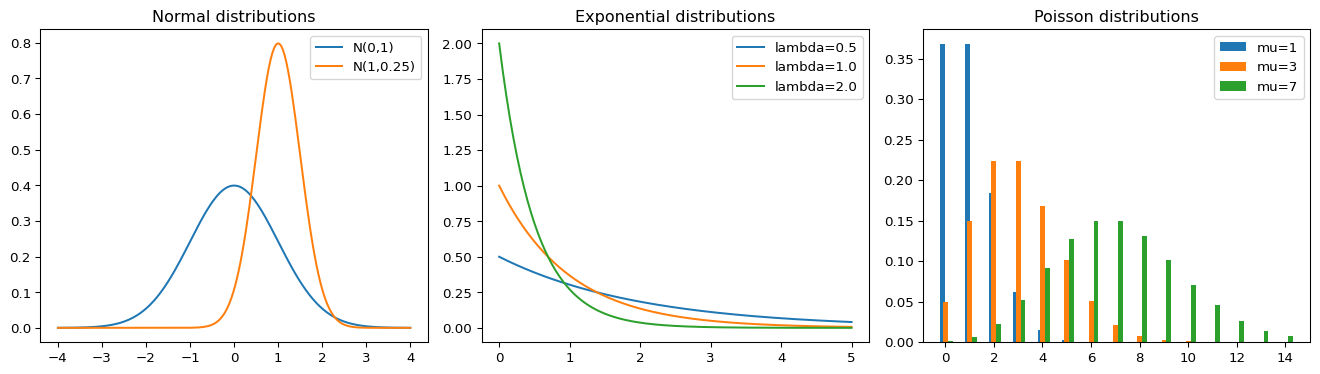

In [10]:
# visualizing distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x = np.linspace(-4, 4, 200)
axes[0].plot(x, stats.norm.pdf(x), label="N(0,1)")
axes[0].plot(x, stats.norm.pdf(x, loc=1, scale=0.5), label="N(1,0.25)")
axes[0].set_title("Normal distributions")
axes[0].legend()

x = np.linspace(0, 5, 200)
for lam in [0.5, 1.0, 2.0]:
    axes[1].plot(x, stats.expon.pdf(x, scale=1/lam), label=f"lambda={lam}")
axes[1].set_title("Exponential distributions")
axes[1].legend()

k = np.arange(0, 15)
for mu in [1, 3, 7]:
    axes[2].bar(k + 0.2*(mu-3)/4, stats.poisson.pmf(k, mu=mu), width=0.2, label=f"mu={mu}")
axes[2].set_title("Poisson distributions")
axes[2].legend()

plt.tight_layout()
plt.show()

## Statistical tests

`scipy.stats` provides many standard statistical tests. Each test
returns a test statistic and a p-value.

- `stats.ttest_1samp(data, popmean)`: one-sample t-test (is the mean
  equal to `popmean`?).
- `stats.ttest_ind(sample1, sample2)`: two-sample t-test (do two
  independent samples have the same mean?).
- `stats.chisquare(observed)`: chi-squared test (do observed frequencies
  match expected frequencies?).
- `stats.kstest(data, 'norm')`: Kolmogorov-Smirnov test (does the data
  come from the given distribution?).

In [11]:
rng = np.random.default_rng(0)
data = rng.normal(loc=5.2, scale=1.0, size=30)

# one-sample t-test
t_stat, p_value = stats.ttest_1samp(data, popmean=5.0)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

t-statistic = 0.5225, p-value = 0.6053

In [12]:
# two-sample t-test
sample1 = rng.normal(loc=5.0, scale=1.0, size=40)
sample2 = rng.normal(loc=5.5, scale=1.0, size=40)

t_stat, p_value = stats.ttest_ind(sample1, sample2)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

t-statistic = -1.2000, p-value = 0.2338

In [13]:
# chi-squared test
observed = np.array([18, 22, 20, 25, 15])
stat, p_value = stats.chisquare(observed)
print(f"chi2-statistic = {stat:.4f}, p-value = {p_value:.4f}")

chi2-statistic = 2.9000, p-value = 0.5747

In [14]:
# Kolmogorov-Smirnov test
data = rng.normal(loc=0, scale=1, size=100)
stat, p_value = stats.kstest(data, 'norm')
print(f"KS statistic = {stat:.4f}, p-value = {p_value:.4f}")

KS statistic = 0.0477, p-value = 0.9689

## Maximum likelihood estimation

Maximum likelihood estimation (MLE) is one of the most important methods
in statistics. Given i.i.d. observations $x_1, \dots, x_n$ from a
distribution with density $f(x; \theta)$, the likelihood function is
$$L(\theta) = \prod_{i=1}^n f(x_i; \theta),$$ and the log-likelihood is
$$\ell(\theta) = \sum_{i=1}^n \log f(x_i; \theta).$$ The MLE is the
parameter value that maximizes $\ell(\theta)$, or equivalently minimizes
$-\ell(\theta)$.

In `scipy.stats`, the `fit` method computes the MLE for any
distribution:

- `dist.fit(data)`: returns the MLE of the distribution parameters.
- `dist.logpdf(x, ...)`: log-density, useful for computing the
  log-likelihood.

For cases where no closed-form MLE exists, we use numerical optimization
via `scipy.optimize.minimize` (see **?@sec-optimization**).

In [15]:
# MLE for the normal distribution
rng = np.random.default_rng(0)
true_mu = 3.0
true_sigma = 1.5
data = rng.normal(loc=true_mu, scale=true_sigma, size=200)

# analytical MLE
mu_hat = np.mean(data)
sigma_hat = np.std(data)  # np.std uses 1/n, which is the MLE
print(f"true mu = {true_mu}, MLE mu = {mu_hat:.4f}")
print(f"true sigma = {true_sigma}, MLE sigma = {sigma_hat:.4f}")

true mu = 3.0, MLE mu = 3.0229
true sigma = 1.5, MLE sigma = 1.4418

In [16]:
# using scipy's fit method
mu_fit, sigma_fit = stats.norm.fit(data)
print(f"scipy fit: mu = {mu_fit:.4f}, sigma = {sigma_fit:.4f}")

scipy fit: mu = 3.0229, sigma = 1.4418

In [17]:
# MLE for the exponential distribution
# For Exp(lambda) with density lambda * exp(-lambda * x), the MLE is lambda_hat = 1 / x_bar
true_lambda = 2.0
data_exp = rng.exponential(scale=1/true_lambda, size=150)  # rng.exponential(scale, size) draws from an exponential distribution

lambda_hat = 1 / np.mean(data_exp)
print(f"true lambda = {true_lambda}, MLE lambda = {lambda_hat:.4f}")

true lambda = 2.0, MLE lambda = 1.7986

In [18]:
# MLE via numerical optimization (when no closed form exists)
# Example: Gamma distribution
from scipy import optimize

true_shape = 2.5
true_scale = 1.3
data_gamma = rng.gamma(shape=true_shape, scale=true_scale, size=300)  # rng.gamma(shape, scale, size) draws from a gamma distribution

def neg_log_likelihood_gamma(params):
    a, scale = params
    if a <= 0 or scale <= 0:
        return np.inf  # np.inf represents positive infinity
    return -np.sum(stats.gamma.logpdf(data_gamma, a=a, scale=scale))

result = optimize.minimize(neg_log_likelihood_gamma, x0=[1.0, 1.0], method='Nelder-Mead')  # Nelder-Mead is a gradient-free optimization method
a_hat, scale_hat = result.x
print(f"true shape = {true_shape}, MLE shape = {a_hat:.4f}")
print(f"true scale = {true_scale}, MLE scale = {scale_hat:.4f}")

true shape = 2.5, MLE shape = 2.7228
true scale = 1.3, MLE scale = 1.1411

In [19]:
# compare with scipy's built-in fit
a_fit, loc_fit, scale_fit = stats.gamma.fit(data_gamma, floc=0)  # floc=0 fixes the location parameter to 0
print(f"scipy fit: shape = {a_fit:.4f}, scale = {scale_fit:.4f}")

scipy fit: shape = 2.7227, scale = 1.1411

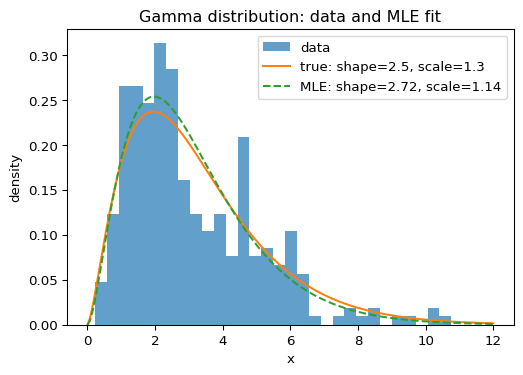

In [20]:
# visualizing the MLE fit
x_grid = np.linspace(0, 12, 200)

plt.figure(figsize=(6, 4))
plt.hist(data_gamma, bins=30, density=True, alpha=0.7, label="data")
plt.plot(x_grid, stats.gamma.pdf(x_grid, a=true_shape, scale=true_scale),
         label=f"true: shape={true_shape}, scale={true_scale}")
plt.plot(x_grid, stats.gamma.pdf(x_grid, a=a_hat, scale=scale_hat),
         label=f"MLE: shape={a_hat:.2f}, scale={scale_hat:.2f}", linestyle="--")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Gamma distribution: data and MLE fit")
plt.legend()
plt.show()

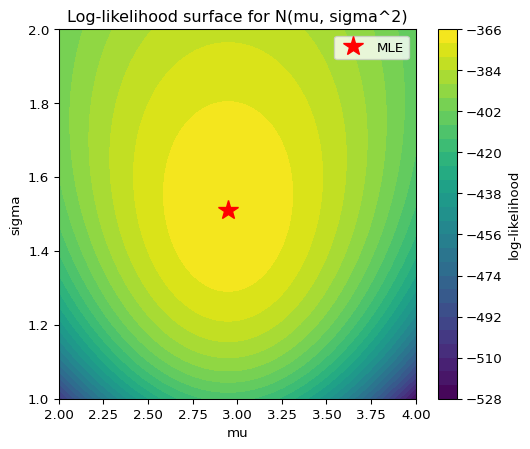

In [21]:
# log-likelihood surface for N(mu, sigma^2)
data = rng.normal(loc=3.0, scale=1.5, size=200)

mu_grid = np.linspace(2.0, 4.0, 100)
sigma_grid = np.linspace(1.0, 2.0, 100)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)  # np.meshgrid creates 2D coordinate grids from 1D arrays

log_lik = np.zeros_like(MU)  # np.zeros_like creates an array of zeros with the same shape
for i in range(len(sigma_grid)):
    for j in range(len(mu_grid)):
        log_lik[i, j] = np.sum(stats.norm.logpdf(data, loc=MU[i, j], scale=SIGMA[i, j]))

plt.figure(figsize=(6, 5))
plt.contourf(MU, SIGMA, log_lik, levels=30, cmap="viridis")
plt.colorbar(label="log-likelihood")
plt.xlabel("mu")
plt.ylabel("sigma")
plt.title("Log-likelihood surface for N(mu, sigma^2)")
mu_mle = np.mean(data)
sigma_mle = np.std(data)
plt.plot(mu_mle, sigma_mle, "r*", markersize=15, label="MLE")
plt.legend()
plt.show()

Plotting the log-likelihood surface helps build geometric intuition: the
MLE is the peak of the surface. For well-behaved models, the surface is
concave near the maximum, and the curvature encodes the precision of the
estimate (related to the Fisher information).